In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def test_function(m):
    return 3 * m ** 2 + 5 * m + 7

In [3]:
x_input = np.arange(-10, 10, 0.1)
y_output = test_function(x_input)

In [4]:
#x_input

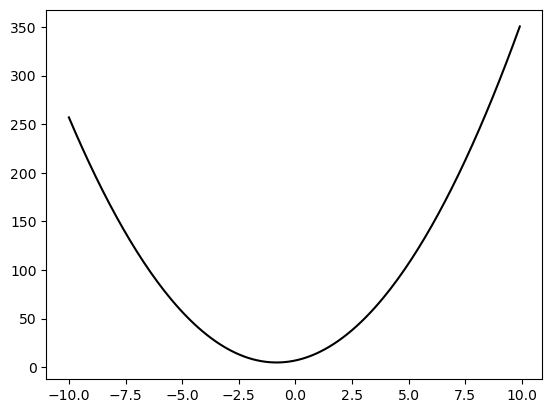

In [5]:
plt.plot(x_input, y_output, color = 'k')
plt.show()

In [6]:
def f1(m):
    return 6 * m + 5

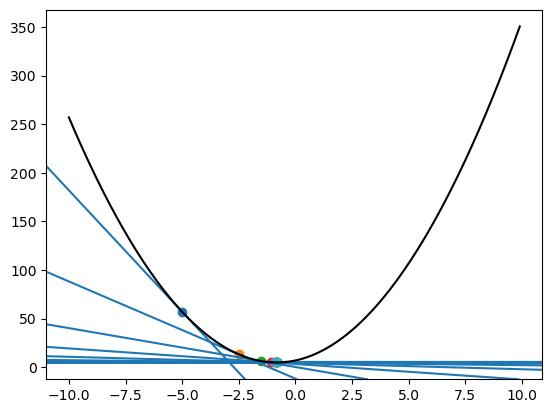

In [7]:
m0 = -5
m_old = m0

alpha = 0.1

for i in range(20):

    m_new = m_old - alpha * f1(m_old)

    #m_old = m_new

    plt.scatter(m_old, test_function(m_old))
    plt.axline((m_old, test_function(m_old)), slope = f1(m_old))

    m_old = m_new

plt.plot(x_input, y_output, color='k')






In [8]:
df = pd.read_csv('~/Teaching/data/Advertising.csv').iloc[:,1:]

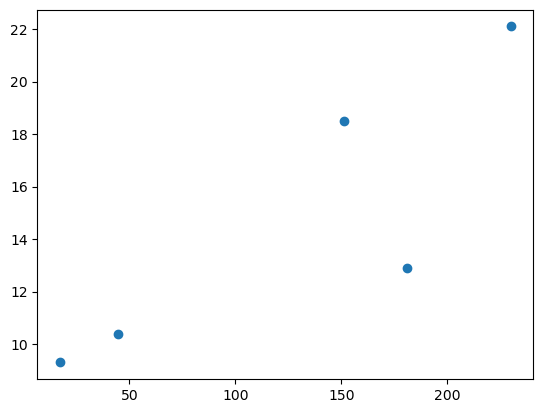

In [9]:
plt.scatter(df.iloc[:5, 0], df.iloc[:5, -1])
plt.show()

In [19]:
def F(w):
    m, b = w
    return ((m * df.iloc[:5, 0] + b - df.iloc[:5, -1]) ** 2).mean()
    

In [20]:
F([1, 1])

np.float64(18295.086000000003)

In [21]:
def F1(w):
    m, b = w
    grad_m = 2 * ((m * df.iloc[:5, 0] + b - df.iloc[:5, -1]) * df.iloc[:5, 0]).mean()
    grad_b = 2 * (m * df.iloc[:5, 0] + b - df.iloc[:5, -1]).mean()
    return grad_m, grad_b

In [22]:
F1([0, 0])

(np.float64(-4337.216), np.float64(-29.28))

In [23]:
alpha = 1e-6
m0 = 0
b0 = 0

for i in range(500):

    g_m, g_b = F1([m0, b0])

    m0 = m0 - alpha * g_m
    b0 = b0 - alpha * g_b

    if i%50 == 0:
        print('MSE is', F([m0, b0]))

MSE is 219.94883030975433
MSE is 28.313576993976817
MSE is 26.25880520089644
MSE is 26.23561608637089
MSE is 26.234197890412343
MSE is 26.233013065553177
MSE is 26.23183081109437
MSE is 26.230648653724995
MSE is 26.229466566936473
MSE is 26.22828455044055


In [24]:
m0, b0

(np.float64(0.09778959991915602), np.float64(0.0029818705670434853))

In [25]:
from scipy.optimize import minimize

In [26]:
res = minimize(F, x0 = [0, 0])

In [27]:
res.x

array([0.0517618 , 8.17909235])

In [28]:
x = df.iloc[:5, 0].values
y = df.iloc[:5, -1].values

x_tilde = (x - x.mean()) / x.std()
y_tilde = (y - y.mean()) / y.std()

In [29]:
def Fnew(w):
    m, b = w
    return ((m * x_tilde + b - y_tilde) ** 2).mean()

In [30]:
Fnew([0,0])

np.float64(1.0)

In [31]:
def F1new(w):
    m, b = w
    grad_m = 2 * ((m * x_tilde + b - y_tilde) * x_tilde ).mean()
    grad_b = 2 * (m * x_tilde + b - y_tilde).mean()

    return grad_m, grad_b

In [32]:
F1new([0,0])

(np.float64(-1.7152637184221031), np.float64(4.4408920985006264e-17))

In [35]:
m0 = 0
b0 = 0
alpha = 0.1

for i in range(50):
    g_m, g_b = F1new([m0, b0])
    m0 = m0 - alpha * g_m
    b0 = b0 - alpha * g_b

    print(Fnew([m0, b0]))

0.7352083338638302
0.5657416675366813
0.45728300108730624
0.3878694545597061
0.34344478478204205
0.3150129961243371
0.2968166513834059
0.2851709907492099
0.27771776794332453
0.27294770534755786
0.2698948652862671
0.26794104764704113
0.2666906043579365
0.26589032065290946
0.2653781390816922
0.2650503428761132
0.2648405533045426
0.26470628797873735
0.26462035817022206
0.2645653630927723
0.2645301662432044
0.264507640259481
0.264493223629898
0.2644839969869649
0.2644780919354877
0.2644743127025423
0.2644718939934573
0.26447034601964275
0.26446935531640153
0.26446872126632714
0.2644683154742795
0.2644680557673691
0.2644678895549463
0.26446778317899583
0.26446771509838746
0.2644676715267981
0.26446764364098097
0.26446762579405797
0.2644676143720273
0.2644676070619277
0.2644676023834638
0.26446759938924697
0.26446759747294823
0.2644675962465171
0.26446759546160103
0.2644675949592548
0.2644675946377533
0.2644675944319923
0.26446759430030525
0.2644675942160255


In [36]:
m0, b0

(np.float64(0.857619618680129), np.float64(5.995204332975846e-17))

In [37]:
m = m0 * y.std()/x.std()
m

np.float64(0.051761082152038264)

In [38]:
b = y.mean() + y.std() * b0 - y.std()/x.std() * m0 * x.mean()
b

np.float64(8.179181725782584)